In [ ]:
from pathlib import Path
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
eval_data_path = Path('../src/evaluation/eval_data')

True

In [4]:
df = pd.read_csv(eval_data_path / 'evaluation_run_c05.csv', index_col=False)
df

,model,test_mae,test_match,test_mAP05,false_alarm,true_alarm
0,best_v8s_640_default_1000e.pt,0.00,16,0.995,0.666667,0.750000
1,best_v8n_640_custom.pt,0.75,5,0.000,0.000000,0.000000
2,best_v8n_640_default_1000e.pt,0.00,16,0.995,0.444444,0.666667
3,best_v11s_640_default_1000e.pt,0.00,16,0.995,0.555556,1.000000
4,best_v8n_640_default.pt,0.00,16,0.995,0.666667,0.666667
5,best_v11n_640_default_1000e.pt,0.00,16,0.995,0.333333,0.833333
6,best_v11n_640_default.pt,0.00,16,0.995,0.777778,0.583333


/tmp/ipykernel_479337/888671200.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='model', y='test_match', ax=ax1, palette='mako', alpha=0.9)
/tmp/ipykernel_479337/888671200.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='model', y='false_alarm', ax=ax2, palette='mako', alpha=0.9)
/tmp/ipykernel_479337/888671200.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='model', y='true_alarm', ax=ax3, palette='mako', alpha=0.9)


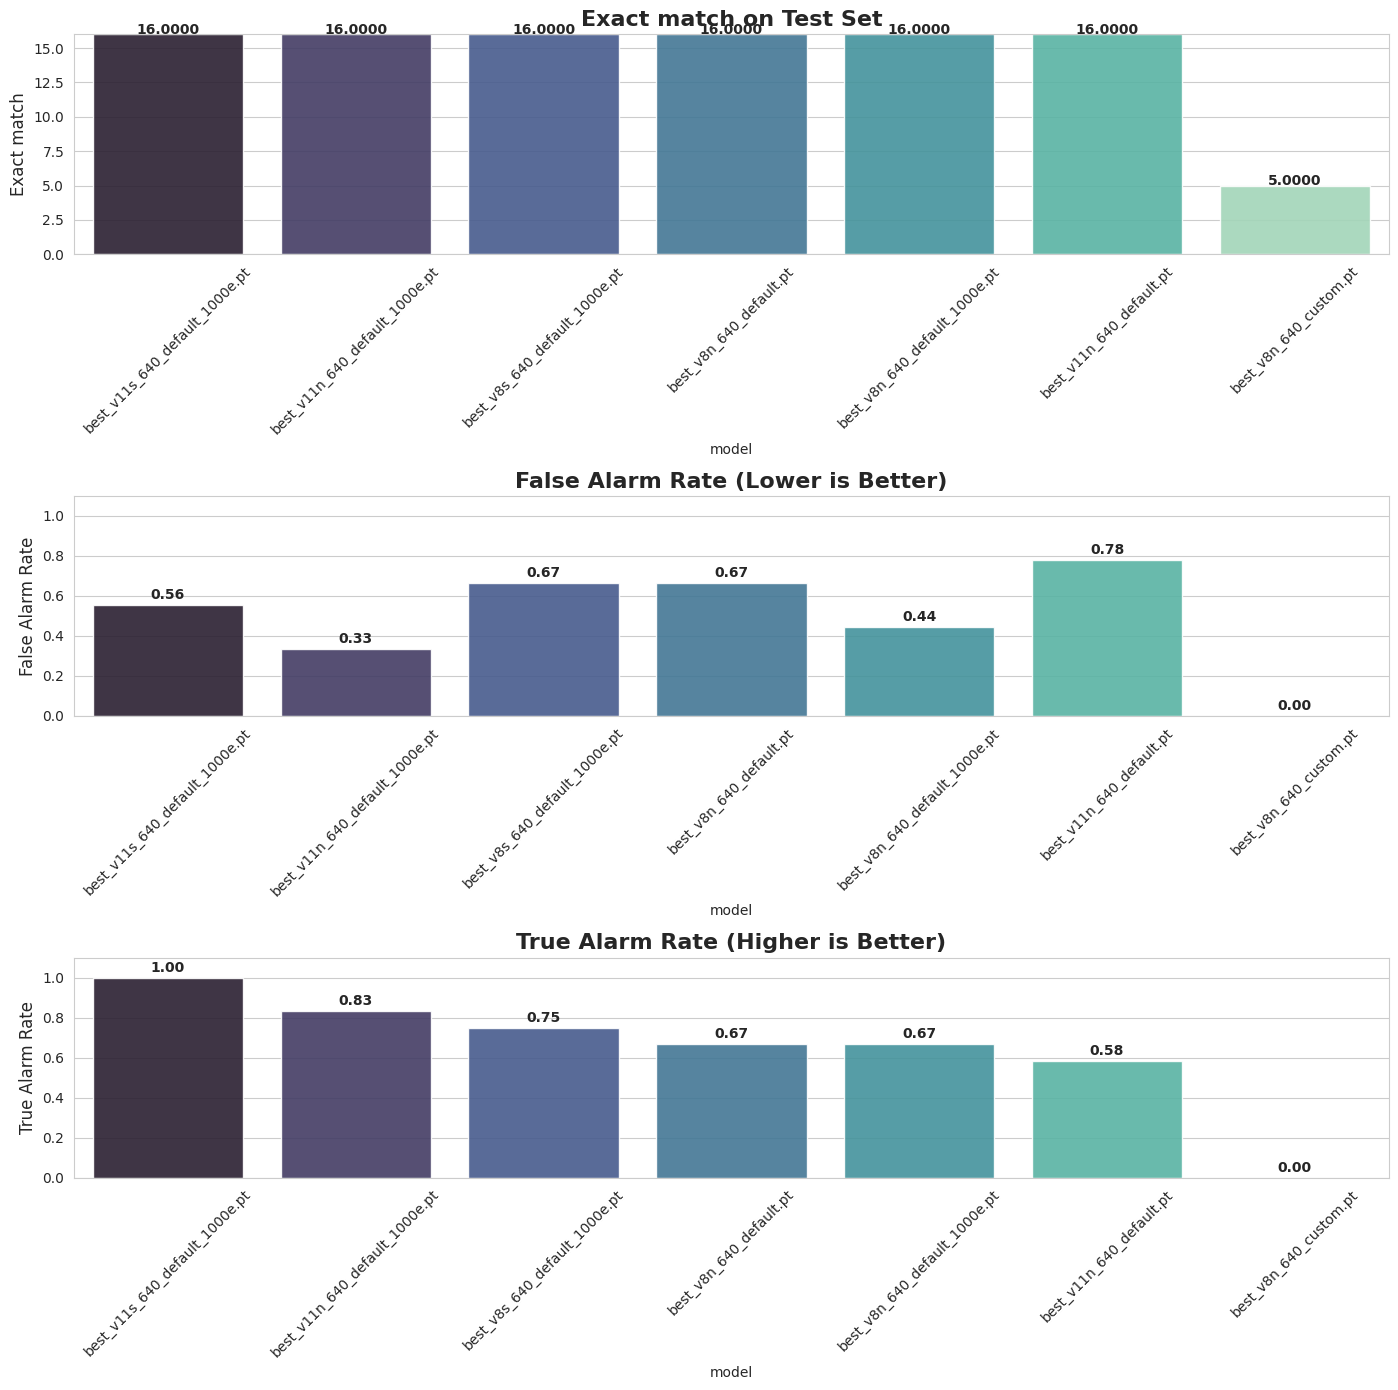

In [13]:
df = df.sort_values(by='true_alarm', ascending=False).reset_index(drop=True)

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 10)

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(14, 14))

# exact match (higher is better)
sns.barplot(data=df, x='model', y='test_match', ax=ax1, palette='mako', alpha=0.9)
ax1.set_title('Exact match on Test Set', fontsize=16, fontweight='bold')
ax1.set_ylabel('Exact match', fontsize=12)
ax1.set_ylim(0, df['test_match'].max())
ax1.tick_params(axis='x', rotation=45)
for i, v in enumerate(df['test_match']):
    ax1.text(i, v + 0.03, f'{v:.4f}', ha='center', fontweight='bold')

# False Alarm Rate (lower better)
sns.barplot(data=df, x='model', y='false_alarm', ax=ax2, palette='mako', alpha=0.9)
ax2.set_title('False Alarm Rate (Lower is Better)', fontsize=16, fontweight='bold')
ax2.set_ylabel('False Alarm Rate', fontsize=12)
ax2.set_ylim(0, 1.1)
ax2.tick_params(axis='x', rotation=45)
for i, v in enumerate(df['false_alarm']):
    ax2.text(i, v + 0.03, f'{v:.2f}', ha='center', fontweight='bold')

# True Alarm Rate (higher better)
sns.barplot(data=df, x='model', y='true_alarm', ax=ax3, palette='mako', alpha=0.9)
ax3.set_title('True Alarm Rate (Higher is Better)', fontsize=16, fontweight='bold')
ax3.set_ylabel('True Alarm Rate', fontsize=12)
ax3.set_ylim(0, 1.1)
ax3.tick_params(axis='x', rotation=45)
for i, v in enumerate(df['true_alarm']):
    ax3.text(i, v + 0.03, f'{v:.2f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()